# Cola de espera por estación — troncal Macrobús T1

Reconstruye cuánta gente está esperando en cada estación de la troncal a lo largo del día,
cruzando las validaciones AFC (personas que entran a esperar) contra los pasos de camión
inferidos del GPS.

Metodología, supuestos y limitaciones en `docs/cola-de-espera.md`.
Generado desde `scripts/build_cola.py`.

---

## Resumen ejecutivo

**1. La cola es corta casi siempre.** Bajo el supuesto de vaciado total, en día hábil de
06 a 20 h la cola mediana al llegar un camión es de **3 personas** y el p95 de **26**. Con
un camión cada ~1.6 min por estación, la espera no es hoy el problema del sistema.

**2. El supuesto de vaciado total se sostiene si la capacidad supera ~60.** El barrido de
capacidades muestra una transición nítida: por debajo de 60 abordajes por paso la cola se
acumula y no se desaloja al cierre del día; por encima converge al modelo de vaciado total.
Como no hay dato de capacidad en la BD, esto convierte el faltante en una pregunta acotada:
basta saber si la capacidad efectiva pasa de 60, no su valor exacto.

**3. La cola absorbe la variación que la oferta no sigue, y la amplifica.** La demanda varía
1.90× entre pico y valle y la oferta sólo 1.25×. La cola varía **2.30×** — más que la propia
demanda — con correlación **+0.94 con la demanda** y **−0.05 con la oferta**. Es la
confirmación mecánica del desacople que reportó el EDA: lo que el despacho no absorbe, lo
absorbe el andén.

**4. T01 queda fuera y no por decisión de alcance.** En T01 la validación es a bordo, así
que el evento AFC *es* el abordaje y no existe cola observable. Ver §1.

**5. Las dos terminales tienen el método sesgado.** Mirador y Fray Angélico registran ~265
pasos/día contra ~525 del resto, porque llegada, layover y salida se fusionan en una sola
visita. Sus colas están sobreestimadas ~2× y deben leerse como cota superior.

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

import db, fleet, stations as st, queues as qu, demand, departures as dp

pd.set_option("display.width", 170)
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
AZUL, NARANJA, VERDE, GRIS = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"

# Misma franja núcleo que el EDA: 05 h y 21–22 h son arranque y cierre, e inflan
# artificialmente cualquier razón pico/valle.
CORE_H = list(range(6, 21))

## 1. Alcance — por qué T01 queda fuera

El brief pide T1 y T01. Los datos sólo permiten T1, y conviene ver la evidencia antes de
seguir: si en una ruta la validación ocurre al abordar, el evento AFC *es* el abordaje y no
hay cola de espera que reconstruir.

In [2]:
SQL_ALCANCE = '''
    SELECT 'T1  (transaction_1)' AS ruta,
           COUNT(DISTINCT idRutaEstacion) AS valores_idRutaEstacion,
           COUNT(DISTINCT idDispositivo)  AS dispositivos
      FROM transaction_1 WHERE idRutaEstacion = 79001001
    UNION ALL
    SELECT 'T01 (transaction_5)', COUNT(DISTINCT idRutaEstacion), COUNT(DISTINCT idDispositivo)
      FROM transaction_5
'''
display(db.q(SQL_ALCANCE))

SQL_PAX = '''
    SELECT id_route, SUM(all_passengers) AS pax_a_bordo
    FROM afc_bus_total WHERE id_route IN (2, 7) GROUP BY id_route
'''
print("Pasajeros contabilizados A BORDO (afc_bus_total):")
print(db.q(SQL_PAX).to_string(index=False))

print()
print("Los 25 dispositivos de transaction_5 contra los id_bus de T01:")
print(db.q("SELECT DISTINCT idDispositivo FROM transaction_5 ORDER BY idDispositivo LIMIT 5")
      .to_string(index=False))
print(db.q("SELECT id_bus, busnumber FROM bus WHERE id_route = 7 ORDER BY id_bus LIMIT 5")
      .to_string(index=False))

,ruta,valores_idRutaEstacion,dispositivos
0,T1 (transaction_1),1,182
1,T01 (transaction_5),1,25


Pasajeros contabilizados A BORDO (afc_bus_total):
 id_route  pax_a_bordo
        2          0.0
        7     818519.0

Los 25 dispositivos de transaction_5 contra los id_bus de T01:
 idDispositivo
            64
            65
            66
            67
            68
 id_bus busnumber
     64    T01/01
     65    T01/02
     66    T01/03
     67    T01/04
     68    T01/05


La evidencia es consistente en tres frentes:

- `transaction_5.idDispositivo` toma los valores 64, 65, 66… que son **exactamente**
  `bus.id_bus` de las unidades T01. El dispositivo de cobro *es* el camión.
- `afc_bus_total` reporta **818 519** pasajeros a bordo en la ruta 7 (T01) y **cero** en la
  ruta 2 (T1). En la troncal nadie valida arriba del camión.
- `transaction_5.idRutaEstacion` tiene un único valor (100, la ruta), mientras que en T1 el
  100 % de las validaciones mapea a una de 27 estaciones.

**Conclusión:** T1 es estación cerrada con validación de entrada — la premisa del brief se
confirma. T01 es validación a bordo y queda fuera, no por alcance sino porque el dato no
existe.

## 2. Qué ya había y qué hubo que construir

El brief pregunta si `src/departures.py`, `bus_location_info` o `in_route_point_control`
ya dan eventos por estación intermedia.

In [3]:
print("bus_location_info — ¿es histórico o snapshot?")
print(db.q('''SELECT COUNT(*) AS filas, COUNT(DISTINCT id_bus) AS buses
              FROM bus_location_info''').to_string(index=False))

print()
print("in_route_point_control (troncal) — puntos por dirección:")
print(db.q('''SELECT direction, COUNT(*) AS puntos
              FROM in_route_point_control WHERE id_route = 2
              GROUP BY direction ORDER BY direction''').to_string(index=False))

bus_location_info — ¿es histórico o snapshot?
 filas  buses
   257    257

in_route_point_control (troncal) — puntos por dirección:
 direction  puntos
         0       2
         1       2
         2       2
         3      25


**`bus_location_info` no sirve:** 257 filas para 257 unidades. Es un *snapshot* del estado
actual (`last`, `next`, `arrival_time_last`), sin historia. No se puede reconstruir nada
hacia atrás con él.

**`src/departures.py` tampoco:** sólo conoce `Terminal_START` y `Terminal_END`, los dos
puntos de `direction = 0`. Detecta salidas de terminal, no pasos por estación intermedia.

**`in_route_point_control` sí aporta la geometría**, pero repartida: 25 estaciones en
`direction = 3` y las dos de los extremos (Fray Angélico, Mirador) en `direction` 1 y 2.
Juntas dan las 27 estaciones que tienen torniquetes en el AFC.

Lo construido en `src/stations.py`:

1. `catalogo_estaciones()` — une geometría con el id del AFC por nombre normalizado.
2. `pings_en_estacion()` — cruza el GPS contra discos de 150 m alrededor de cada estación.
3. `pasos_de_camion()` — agrupa pings contiguos en visitas.
4. `completar_pasos()` — reconstruye los pasos que el GPS no alcanzó a registrar.

## 3. Catálogo de estaciones y cadena de identidad

Para llegar de una validación a su estación hay que encadenar tres saltos, y el nombre de
la columna estorba más de lo que ayuda: `transaction_1.idRutaEstacion` **no** es la
estación, es la ruta. `idUbicacion` es 0 en toda la troncal.

In [4]:
cat = st.catalogo_estaciones()
print(f"estaciones: {len(cat)}")
display(cat.head(6))

SQL_MAPEO = '''
    SELECT COUNT(*) AS validaciones,
           ROUND(100 * SUM(m.id_station IS NOT NULL) / COUNT(*), 2) AS pct_con_estacion
    FROM transaction_1 t
    LEFT JOIN (SELECT DISTINCT id_vehicle, id_station FROM afc_station_device_total) m
           ON m.id_vehicle = t.idDispositivo
    WHERE t.idRutaEstacion = 79001001
'''
print("Cobertura de la cadena idDispositivo -> id_vehicle -> id_station:")
print(db.q(SQL_MAPEO, cache="cobertura_estacion").to_string(index=False))

estaciones: 27


,id_station,name,orden,lat,lon
0,7900011,Mirador,1,20.736407,-103.312381
1,7900012,Huentitán,2,20.732241,-103.313648
2,7900013,Zoológico,3,20.726670,-103.315301
3,7900014,Independencia Norte,4,20.720119,-103.317532
4,7900015,San Patricio,5,20.715693,-103.319961
5,7900016,Igualdad,6,20.711521,-103.322219


Cobertura de la cadena idDispositivo -> id_vehicle -> id_station:
 validaciones  pct_con_estacion
      5523090             100.0


## 4. Pasos de camión por estación

El GPS muestrea cada ~20 s. A 50 km/h una unidad avanza 278 m entre pings, así que puede
cruzar un disco de 150 m sin dejar rastro. Eso importa: un paso no detectado hace creer al
modelo que nadie recogió a esa gente, e infla la cola.

La corrección aprovecha que **la ruta es fija y sin ramales**: si una unidad aparece en la
estación de orden 5 y luego en la de orden 8, forzosamente pasó por 6 y 7.

In [5]:
pings = st.pings_en_estacion()
pasos_obs = st.pasos_de_camion(pings)
pasos = st.completar_pasos(pasos_obs, cat)
nd = pasos["fecha"].nunique()

print(f"pings dentro de disco de estación : {len(pings):,}")
print(f"pasos observados                  : {len(pasos_obs):,}  ({len(pasos_obs)/nd:,.0f}/día)")
print(f"pasos tras reconstrucción         : {len(pasos):,}  ({len(pasos)/nd:,.0f}/día)")
print(f"proporción reconstruida           : {100*pasos['interpolado'].mean():.1f}%")

pings dentro de disco de estación : 3,036,214
pasos observados                  : 617,812  (9,965/día)
pasos tras reconstrucción         : 837,676  (13,511/día)
proporción reconstruida           : 26.2%


In [6]:
# Validación independiente: los pasos por estación deberían igualar el número de vueltas
# diarias, que src/departures.py deriva por otro camino (salidas de terminal).
term = dp.terminales(2)
sur = term[term.name.str.contains("START")].iloc[0]
nte = term[term.name.str.contains("END")].iloc[0]
sal = dp.detectar_salidas(dp.pings_en_terminal(fleet.TRONCAL_T1, sur.latitude, sur.longitude,
                                               nte.latitude, nte.longitude))
vueltas_dia = len(sal) / sal["fecha"].nunique()

ppd = pasos.groupby("id_station").size() / nd
print(f"vueltas/día según departures.py (terminales) : {vueltas_dia:,.0f}")
print(f"pasos/día por estación, mediana              : {ppd.median():,.0f}")
print(f"pasos/día por estación, rango                : {ppd.min():,.0f} – {ppd.max():,.0f}")

vueltas/día según departures.py (terminales) : 526
pasos/día por estación, mediana              : 525
pasos/día por estación, rango                : 270 – 536


La mediana de pasos por estación converge al número de vueltas diarias derivado por un
camino totalmente distinto (salidas de terminal). Es una validación cruzada razonable de
que la reconstrucción no está inventando pasos.

### El sesgo de las terminales

Las dos estaciones de los extremos son la excepción, y hay que tenerlo presente al leer los
resultados.

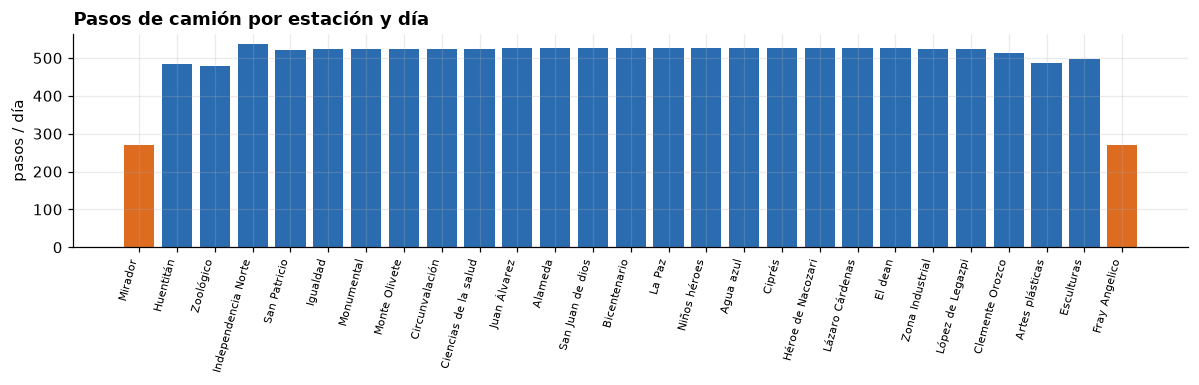

 orden          name  pasos_dia
     1       Mirador      271.0
    27 Fray Angelico      270.0


In [7]:
freq = pd.DataFrame({"pasos_dia": pasos.groupby("id_station").size() / nd})
freq = freq.join(cat.set_index("id_station")[["name", "orden"]]).sort_values("orden")

fig, ax = plt.subplots(figsize=(11, 3.6))
col = [NARANJA if p < 350 else AZUL for p in freq["pasos_dia"]]
ax.bar(range(len(freq)), freq["pasos_dia"], color=col)
ax.set_xticks(range(len(freq))); ax.set_xticklabels(freq["name"], rotation=75, ha="right", fontsize=7)
ax.set_title("Pasos de camión por estación y día", loc="left", weight="bold")
ax.set_ylabel("pasos / día")
plt.tight_layout(); plt.show()

print(freq[freq["pasos_dia"] < 350][["orden", "name", "pasos_dia"]].round(0).to_string(index=False))

En Mirador y Fray Angélico la unidad llega, hace base y sale: los pings quedan contiguos y
se fusionan en **una sola visita** en vez de dos pasos. Resultado: ~265 pasos/día contra
~525 del resto, y por tanto intervalos del doble y colas estimadas del doble.

**Las colas de esas dos estaciones son cota superior, no estimación.** No es un detalle
menor: Fray Angélico es la estación de mayor volumen de toda la troncal.

## 5. Flujo: personas que llegan entre paso y paso

Los dos flujos sólo interactúan en los instantes de paso, así que no hace falta simular
minuto a minuto: basta contar cuántas personas validaron entre un camión y el siguiente.

In [8]:
ent = st.entradas_afc()
flujo = qu.llegadas_entre_pasos(ent, pasos)

print(f"filas AFC (estación × minuto) : {len(ent):,}")
print(f"validaciones totales          : {ent['entradas'].sum():,}")
print(f"pasos con flujo asignado      : {len(flujo):,}")
print(f"validaciones asignadas        : {flujo['llegadas'].sum():,} "
      f"({100*flujo['llegadas'].sum()/ent['entradas'].sum():.1f}%)")
print()
print("El 3.5% restante cae fuera de la franja de servicio o antes del primer paso del día.")

filas AFC (estación × minuto) : 1,309,682
validaciones totales          : 5,523,090
pasos con flujo asignado      : 836,720
validaciones asignadas        : 5,330,995 (96.5%)

El 3.5% restante cae fuera de la franja de servicio o antes del primer paso del día.


## 6. Modelo (a) — vaciado total

Supuesto del brief: cada camión se lleva a todos los que esperan. La cola al llegar el
camión *i* es simplemente lo que se acumuló desde el paso anterior.

Es un **piso**: si con este supuesto ya salen colas grandes, la realidad sólo puede ser
peor.

Cola al llegar el camión — día hábil 06–20 h
count    583155.0
mean          6.8
std          14.2
min           0.0
50%           3.0
75%           8.0
90%          17.0
95%          26.0
99%          57.0
max        1759.0


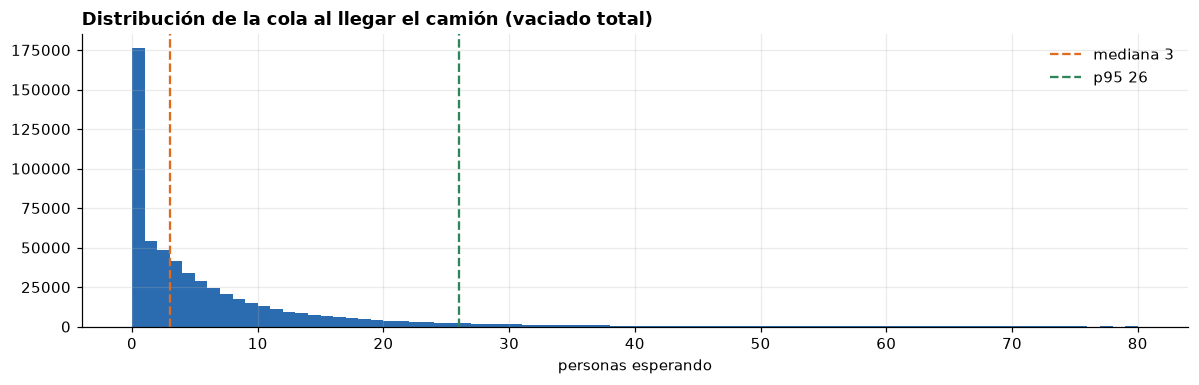

In [9]:
a = qu.cola_vaciado_total(flujo)
op = a[a["hora"].isin(CORE_H) & ~a["finde"]]

print("Cola al llegar el camión — día hábil 06–20 h")
print(op["cola"].describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.hist(op[op["cola"] <= 80]["cola"], bins=80, color=AZUL)
ax.axvline(op["cola"].median(), color=NARANJA, ls="--", label=f"mediana {op['cola'].median():.0f}")
ax.axvline(op["cola"].quantile(.95), color=VERDE, ls="--", label=f"p95 {op['cola'].quantile(.95):.0f}")
ax.set_title("Distribución de la cola al llegar el camión (vaciado total)", loc="left", weight="bold")
ax.set_xlabel("personas esperando"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

La cola típica es **muy corta**. Con un camión cada ~1.6 min por estación, la mediana es de
3 personas. La espera no es hoy el cuello de botella del sistema.

## 7. Modelo (b) — capacidad finita

Si el camión sólo puede llevarse `C` personas, el resto se queda para el siguiente:

    cola_i = max(0, cola_{i-1} − C) + llegadas_i

No hay dato de capacidad en la BD. Pero sí se puede barrer `C` y ver a partir de qué valor
las colas dejan de acumularse — lo que convierte el faltante en una pregunta acotada.

,capacidad,cola_media,cola_p95,pct_no_desaloja,residual_p95,residual_cierre_medio
0,10,300.12,1526.3,36.17,1516.3,724.66
1,20,129.39,123.0,12.80,103.0,311.80
2,30,88.05,39.0,6.30,9.0,154.82
3,40,60.38,32.0,3.93,0.0,53.78
4,50,37.31,30.0,2.70,0.0,3.47
5,60,23.17,28.0,1.84,0.0,0.48
6,80,11.54,27.0,0.96,0.0,0.00
7,120,7.28,26.0,0.36,0.0,0.00
8,160,6.96,26.0,0.16,0.0,0.00


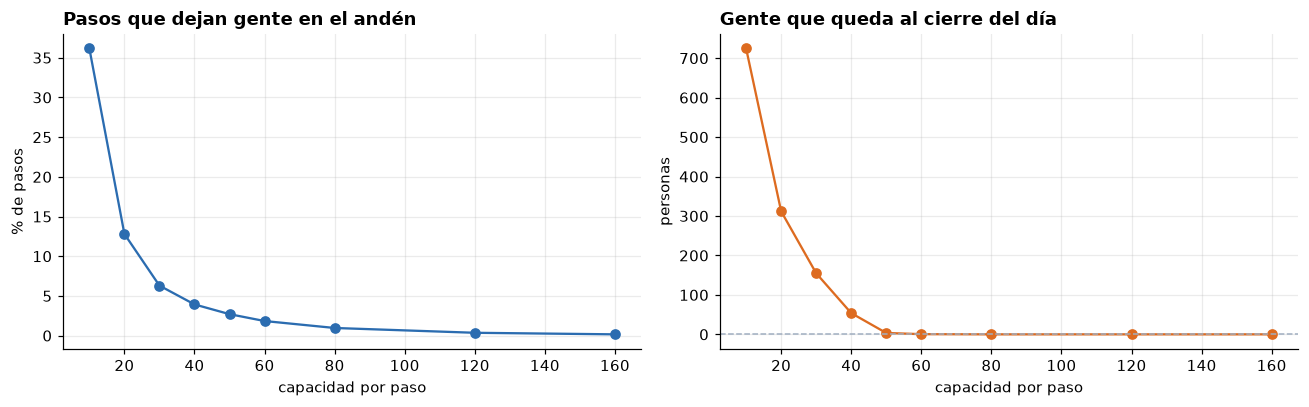

cola media con vaciado total          : 6.78
cola media con capacidad 160           : 6.96


In [10]:
barrido = qu.barrido_capacidad(op, [10, 20, 30, 40, 50, 60, 80, 120, 160])
display(barrido.round(2))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(barrido["capacidad"], barrido["pct_no_desaloja"], marker="o", color=AZUL)
a1.set_title("Pasos que dejan gente en el andén", loc="left", weight="bold")
a1.set_xlabel("capacidad por paso"); a1.set_ylabel("% de pasos")

a2.plot(barrido["capacidad"], barrido["residual_cierre_medio"], marker="o", color=NARANJA)
a2.axhline(0, color=GRIS, ls="--", lw=1)
a2.set_title("Gente que queda al cierre del día", loc="left", weight="bold")
a2.set_xlabel("capacidad por paso"); a2.set_ylabel("personas")
plt.tight_layout(); plt.show()

print(f"cola media con vaciado total          : {op['cola'].mean():.2f}")
print(f"cola media con capacidad 160           : {barrido.iloc[-1]['cola_media']:.2f}")

La transición es nítida. Por debajo de **C ≈ 60** el sistema no alcanza a desalojar y la
gente se acumula hasta el cierre; por encima, el residual se va a cero y la cola media
converge al valor del modelo (a).

**Conclusión sobre el supuesto del brief:** el vaciado total es defendible *siempre que la
capacidad efectiva por paso supere ~60 personas*. Un articulado de BRT ronda 100–160, así
que el supuesto probablemente se sostiene — pero eso hay que confirmarlo con el cliente.

Y esto reformula la pregunta pendiente de capacidad: para este análisis no hace falta el
número exacto, basta saber **si supera 60**.

## 8. Curvas de cola por estación y por hora

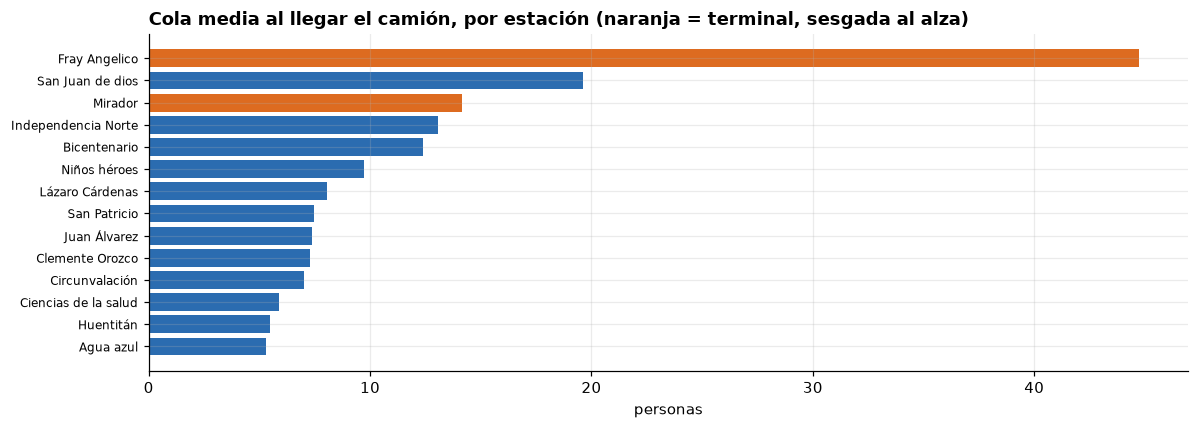

,orden,name,media,mediana,p95,terminal
id_station,,,,,,
7900037,27,Fray Angelico,44.7,25.0,163.0,True
7900023,13,San Juan de dios,19.6,13.0,62.0,False
7900011,1,Mirador,14.2,9.0,47.0,True
7900014,4,Independencia Norte,13.1,9.0,43.0,False
7900024,14,Bicentenario,12.4,8.0,39.0,False
7900026,16,Niños héroes,9.7,7.0,30.0,False
7900030,20,Lázaro Cárdenas,8.0,5.0,28.0,False
7900015,5,San Patricio,7.5,5.0,24.0,False
7900021,11,Juan Álvarez,7.4,5.0,24.0,False


In [11]:
por_est = op.groupby("id_station")["cola"].agg(
    media="mean", mediana="median", p95=lambda s: s.quantile(.95))
por_est = por_est.join(cat.set_index("id_station")[["name", "orden"]])
por_est["terminal"] = por_est["orden"].isin([1, 27])
por_est = por_est.sort_values("media", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
top = por_est.head(14).iloc[::-1]
col = [NARANJA if t else AZUL for t in top["terminal"]]
ax.barh(range(len(top)), top["media"], color=col)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top["name"], fontsize=8)
ax.set_title("Cola media al llegar el camión, por estación (naranja = terminal, sesgada al alza)",
             loc="left", weight="bold")
ax.set_xlabel("personas")
plt.tight_layout(); plt.show()

display(por_est.head(10)[["orden", "name", "media", "mediana", "p95", "terminal"]].round(1))

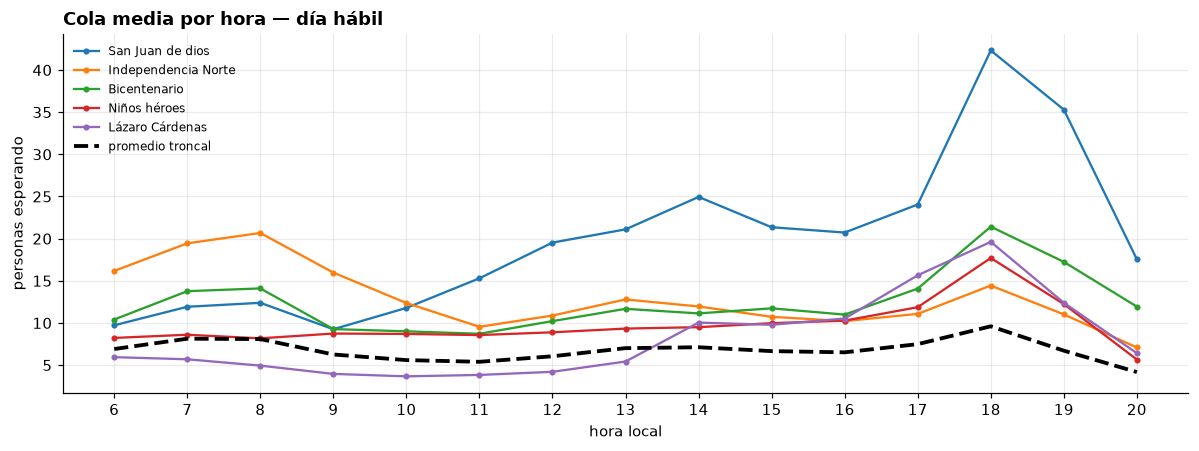

      media   p95  pasos
hora                    
6       6.9  24.0  35486
7       8.1  29.0  43090
8       8.1  28.0  43691
9       6.3  23.0  41471
10      5.6  21.0  37639
11      5.4  21.0  38534
12      6.0  23.0  39390
13      7.0  27.0  37997
14      7.1  27.0  37654
15      6.7  26.0  38112
16      6.5  24.0  37826
17      7.5  28.0  37086
18      9.6  37.0  36512
19      6.7  28.0  38975
20      4.2  18.0  39692


In [12]:
# Curvas horarias de las estaciones de mayor volumen, excluyendo terminales para no
# leer el sesgo como si fuera señal.
top_est = por_est[~por_est["terminal"]].head(5).index

fig, ax = plt.subplots(figsize=(11, 4.2))
for est in top_est:
    s = op[op["id_station"] == est].groupby("hora")["cola"].mean()
    ax.plot(s.index, s.values, marker="o", ms=3, label=cat.set_index("id_station").loc[est, "name"])
glob = op.groupby("hora")["cola"].mean()
ax.plot(glob.index, glob.values, color="black", lw=2.5, ls="--", label="promedio troncal")
ax.set_title("Cola media por hora — día hábil", loc="left", weight="bold")
ax.set_xlabel("hora local"); ax.set_ylabel("personas esperando")
ax.set_xticks(CORE_H); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(op.groupby("hora")["cola"].agg(media="mean", p95=lambda s: s.quantile(.95),
                                     pasos="size").round(1).to_string())

## 9. Contraste con el desacople oferta/demanda

El EDA encontró que la oferta es plana (razón pico/valle 1.25) frente a una demanda que
varía 1.90×, con correlación nula entre ambas. La pregunta natural: ¿dónde se absorbe esa
diferencia?

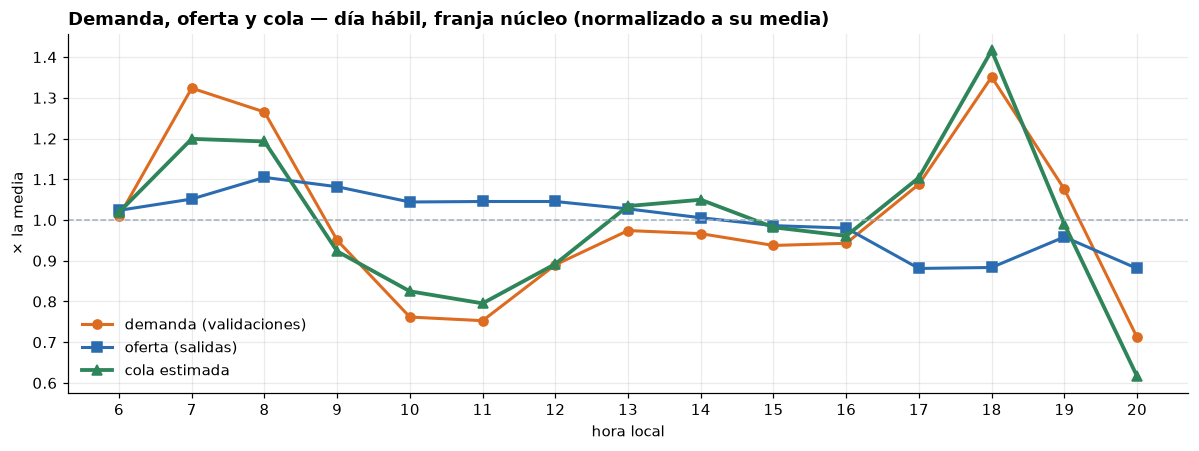

,serie,razón pico/valle,corr. con demanda,corr. con oferta
0,demanda,1.898,1.000,-0.027
1,oferta,1.254,-0.027,1.000
2,cola,2.298,0.942,-0.052


In [13]:
# Demanda por hora (validaciones), día hábil
dh = demand.demanda_por_hora()
dm = dh[~dh["finde"].astype(bool)].set_index("hora")
dem_h = (dm["validaciones"] / dm["dias"]).reindex(CORE_H)

# Oferta por hora (salidas desde terminal sur), día hábil
hab = sal[~sal["finde"]]
ofe_h = (hab[hab["desde"] == "SUR"].groupby("hora").size() / hab["fecha"].nunique()).reindex(CORE_H)

# Cola por hora
cola_h = op.groupby("hora")["cola"].mean().reindex(CORE_H)

norm = lambda s: s / s.mean()
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(CORE_H, norm(dem_h), marker="o", color=NARANJA, lw=2, label="demanda (validaciones)")
ax.plot(CORE_H, norm(ofe_h), marker="s", color=AZUL, lw=2, label="oferta (salidas)")
ax.plot(CORE_H, norm(cola_h), marker="^", color=VERDE, lw=2.5, label="cola estimada")
ax.axhline(1, color=GRIS, ls="--", lw=1)
ax.set_title("Demanda, oferta y cola — día hábil, franja núcleo (normalizado a su media)",
             loc="left", weight="bold")
ax.set_xlabel("hora local"); ax.set_ylabel("× la media")
ax.set_xticks(CORE_H); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

res = pd.DataFrame({
    "serie": ["demanda", "oferta", "cola"],
    "razón pico/valle": [dem_h.max()/dem_h.min(), ofe_h.max()/ofe_h.min(), cola_h.max()/cola_h.min()],
    "corr. con demanda": [1.0, np.corrcoef(ofe_h, dem_h)[0, 1], np.corrcoef(cola_h, dem_h)[0, 1]],
    "corr. con oferta": [np.corrcoef(dem_h, ofe_h)[0, 1], 1.0, np.corrcoef(cola_h, ofe_h)[0, 1]],
})
display(res.round(3))

La cola sigue a la demanda, no a la oferta: correlación **+0.94** con la primera y **−0.05**
con la segunda. Y no sólo la sigue — la **amplifica**: su razón pico/valle (2.30) supera a la
de la demanda (1.90), precisamente porque la oferta no aporta nada en el pico.

Es la lectura mecánica del desacople: **lo que el despacho no absorbe, lo absorbe el
andén.** Dicho de otro modo, el sistema hoy amortigua la variación de demanda dejando que
la gente espere un poco más, en vez de ajustando cuántos camiones salen.

Ahora bien, la magnitud importa: aun en el pico la cola media ronda 10 personas. **El
margen del agente no está en rescatar a gente varada — no la hay — sino en el otro término
de la recompensa: hay demasiados camiones circulando en las horas valle.**

## 10. Features candidatas para el estado del agente

Del análisis salen features que se pueden materializar por estación y ventana de tiempo.
El destino es Parquet en `data/export/`, no MySQL en el loop de entrenamiento.

| Feature | Definición | Por qué sirve |
|---|---|---|
| `llegadas_estacion_15m` | validaciones en los últimos 15 min | Demanda observada reciente, la señal más directa |
| `cola_estimada` | acumulado desde el último paso | Estado que la acción modifica directamente |
| `cola_p95_hist` | p95 histórico para esa estación-hora-dow | Referencia de lo normal, separa anomalía de patrón |
| `min_desde_ultimo_paso` | minutos desde el paso anterior | Proxy del headway realizado, capta el bunching |
| `pasos_ultima_hora` | pasos en los últimos 60 min | Oferta efectiva reciente por estación |
| `tiempo_recorrido_actual` | mediana de recorrido en la última hora | El tiempo de vuelta no es constante (EDA §5) |
| `cola_aguas_abajo` | suma de colas en estaciones siguientes | Anticipa saturación antes de despachar |

Dos advertencias para el diseño de la recompensa:

- **La cola no está observada, está estimada.** Depende del supuesto de capacidad (§7) y de
  la reconstrucción de pasos (§4). Entrenar contra ella es entrenar contra un modelo, no
  contra la realidad. Conviene tratar sus parámetros como hiperparámetros y verificar que
  la política no dependa de valores concretos.
- **La demanda insatisfecha sigue sin observarse.** El AFC registra a quien entra, no a
  quien vio la fila y se fue. La cola estimada es un piso de la demanda real.

## 11. Limitaciones

Detalladas en `docs/cola-de-espera.md`. Las que más pesan:

1. **Sesgo en terminales** (§4). Mirador y Fray Angélico sobreestiman ~2×.
2. **El AFC no registra sentido.** Por cada estación pasan camiones en ambas direcciones y
   la cola se trata como una sola, lo que sobreestima la capacidad de desalojo.
3. **26 % de los pasos son reconstruidos**, no observados (§4).
4. **La capacidad es un parámetro, no un dato** (§7).
5. **Sólo se ve la demanda atendida**, nunca la que desistió.